# ASEAN Tourism Recovery & Economic Resilience Analysis (2019-2027)

**Analisis Dampak Pandemi COVID-19, Metrik Ketangguhan Sektor Pariwisata, dan Proyeksi Pemulihan Regional**

---

## 1. Pendahuluan & Latar Belakang
Pandemi global COVID-19 (2020-2022) merupakan krisis paling parah yang pernah dihadapi sektor pariwisata internasional. Kawasan Asia Tenggara (ASEAN), yang sangat bergantung pada sektor pariwisata sebagai motor pertumbuhan ekonomi, mengalami penurunan kunjungan wisatawan asing secara drastis.

Notebook ini menyajikan analisis data time-series (2019-2025) kunjungan wisatawan mancanegara ke negara-negara ASEAN dengan tujuan:
1. **Menganalisis Tren Dampak Pandemi**: Mengukur keparahan penurunan pariwisata (*Drop Severity*) di setiap negara.
2. **Menghitung Indeks Ketangguhan**: Mengukur seberapa tangguh suatu negara bangkit kembali (*Recovery Rate* dan *Resilience Score*).
3. **Membuat Proyeksi Pertumbuhan (2026-2027)**: Memodelkan tren pertumbuhan menggunakan regresi tren linier fase pemulihan.
4. **Mempersiapkan Data**: Mengintegrasikan hasil analisis ke dalam Dashboard Web interaktif.

## 2. Persiapan & Import Library
Kita akan menggunakan beberapa pustaka standar Python untuk analisis data dan visualisasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

## 3. Loading & Eksplorasi Data Mentah
Membaca dataset pariwisata dari file Excel `dataset/pivot.xlsx`.

In [2]:
excel_path = 'dataset/pivot.xlsx'
xl = pd.ExcelFile(excel_path)
print("Daftar Sheet:", xl.sheet_names)

# Membaca sheet pertama
df_raw = xl.parse(xl.sheet_names[0])
print("Dimensi data mentah:", df_raw.shape)
df_raw.head(10)

Daftar Sheet: ['Visitor Arrival to ASEAN Me...']
Dimensi data mentah: (14, 9)


,Visitor Arrival to ASEAN Member States by Origin Countries (in person),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,Year,NaN,NaN,NaN,NaN,NaN,NaN
1,Destination Country,Origin Country,2019,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0
2,ASEAN,Total Country (World),147796972,27184224.0,3060897.0,44206300.0,104132183.0,140576987.0,147044420.0
3,Brunei Darussalam,Total Country (World),4449028,1070614.0,110391.0,664259.0,2267960.0,678037.0,741050.0
4,Cambodia,Total Country (World),6610592,1306143.0,196495.0,2276626.0,5453231.0,6700125.0,5569752.0
5,Indonesia,Total Country (World),16106954,4052923.0,1557530.0,5889031.0,11677825.0,14347813.0,15386646.0
6,Lao PDR,Total Country (World),4791065,886447.0,NaN,1294365.0,3417629.0,4120832.0,4580709.0
7,Malaysia,Total Country (World),26100784,4332722.0,134728.0,10070964.0,20141846.0,37961485.0,42196892.0
8,Myanmar,Total Country (World),4364101,903343.0,130947.0,233487.0,1284731.0,1063072.0,973263.0
9,Philippines,Total Country (World),8260913,1482535.0,163879.0,2653858.0,5450557.0,5949350.0,6484060.0


## 4. Pembersihan Data & Restrukturisasi
Struktur tabel di Excel memiliki baris header ganda dan kolom kosong. Kita perlu mengekstrak baris header yang tepat, menyelaraskan nama kolom (negara tujuan, negara asal, dan tahun-tahun), serta menghapus baris metadata yang tidak diperlukan.

In [3]:
# Baris index 1 berisi nama kolom yang benar
columns = df_raw.iloc[1].tolist()
columns[0] = 'destination_country'
columns[1] = 'origin_country'

# Ubah float years (2019.0, 2020.0) menjadi nama kolom string integer ('2019', '2020', dsb.)
for i in range(2, len(columns)):
    columns[i] = str(int(float(columns[i])))

df_clean = df_raw.copy()
df_clean.columns = columns

# Hapus baris 0 dan 1 yang hanya berisi metadata Excel
df_clean = df_clean.iloc[2:].reset_index(drop=True)

# Ubah nilai kolom numerik (tahun) menjadi numeric dan tangani missing value (NaN)
years = [col for col in df_clean.columns if col not in ['destination_country', 'origin_country']]
for yr in years:
    df_clean[yr] = pd.to_numeric(df_clean[yr], errors='coerce')

print("Data setelah dibersihkan:")
df_clean

Data setelah dibersihkan:


,destination_country,origin_country,2019,2020,2021,2022,2023,2024,2025
0,ASEAN,Total Country (World),147796972,27184224.0,3060897.0,44206300.0,104132183.0,140576987.0,147044420.0
1,Brunei Darussalam,Total Country (World),4449028,1070614.0,110391.0,664259.0,2267960.0,678037.0,741050.0
2,Cambodia,Total Country (World),6610592,1306143.0,196495.0,2276626.0,5453231.0,6700125.0,5569752.0
3,Indonesia,Total Country (World),16106954,4052923.0,1557530.0,5889031.0,11677825.0,14347813.0,15386646.0
4,Lao PDR,Total Country (World),4791065,886447.0,NaN,1294365.0,3417629.0,4120832.0,4580709.0
5,Malaysia,Total Country (World),26100784,4332722.0,134728.0,10070964.0,20141846.0,37961485.0,42196892.0
6,Myanmar,Total Country (World),4364101,903343.0,130947.0,233487.0,1284731.0,1063072.0,973263.0
7,Philippines,Total Country (World),8260913,1482535.0,163879.0,2653858.0,5450557.0,5949350.0,6484060.0
8,Singapore,Total Country (World),19113842,2742443.0,330059.0,6305744.0,13610404.0,16529942.0,16910000.0
9,Thailand,Total Country (World),39916251,6702396.0,427869.0,11153026.0,28150016.0,35545713.0,32974321.0


## 5. Rekayasa Fitur: Indeks Ketangguhan Pariwisata (*Resilience Index*)
Untuk mengukur performa setiap negara secara kuantitatif, kita formulasikan metrik baru:
1. **Drop Severity (%)**: Persentase penurunan dari level normal (2019) ke tingkat terendah selama pandemi (2020-2021).
   $$Drop\;Severity = \frac{\min(Value_{2020}, Value_{2021}) - Value_{2019}}{Value_{2019}} \times 100$$
2. **Drop Retained (%)**: Sisa pariwisata yang bertahan saat puncak pandemi.
   $$Drop\;Retained = 100 + Drop\;Severity$$
3. **Recovery Rate 2025 (%)**: Persentase kapasitas pariwisata tahun 2025 dibanding 2019.
   $$Recovery\;Rate = \frac{Value_{2025}}{Value_{2019}} \times 100$$
4. **Years to Recover**: Tahun pertama di mana kunjungan menyamai atau melebihi tahun 2019.
5. **Resilience Score**: Skor komposit gabungan dari ketahanan terendah dan tingkat pemulihan.
   $$Resilience\;Score = Recovery\;Rate + Drop\;Retained$$

In [4]:
resilience_data = []

for _, row in df_clean.iterrows():
    country = row['destination_country']
    
    # Data historis
    val_2019 = row['2019']
    val_2020 = row['2020']
    val_2021 = row['2021']
    val_2025 = row['2025']
    
    # Titik Terendah Pandemi
    vals_pandemic = [v for v in [val_2020, val_2021] if not pd.isna(v)]
    min_val = min(vals_pandemic) if vals_pandemic else np.nan
    
    # Hitung metrik jika data 2019 tersedia
    if not pd.isna(val_2019):
        drop_severity = ((min_val - val_2019) / val_2019) * 100
        drop_retained = 100 + drop_severity
        recovery_rate = (val_2025 / val_2019) * 100 if not pd.isna(val_2025) else np.nan
        
        # Cari tahun pulih penuh
        years_to_recover = 'Not fully recovered'
        for yr in ['2022', '2023', '2024', '2025']:
            if not pd.isna(row[yr]) and row[yr] >= val_2019:
                years_to_recover = yr
                break
                
        resilience_score = recovery_rate + drop_retained if not pd.isna(recovery_rate) else 0
        
        resilience_data.append({
            'Negara': country,
            'Kunjungan 2019': int(val_2019),
            'Titik Terendah': int(min_val),
            'Drop Severity (%)': round(drop_severity, 2),
            'Recovery Rate 2025 (%)': round(recovery_rate, 2),
            'Tahun Pulih': years_to_recover,
            'Resilience Score': round(resilience_score, 2)
        })

df_metrics = pd.DataFrame(resilience_data)
# Urutkan berdasarkan Skor Ketangguhan tertinggi (tidak termasuk regional total 'ASEAN' agar peringkat valid)
df_ranking = df_metrics[df_metrics['Negara'] != 'ASEAN'].sort_values(by='Resilience Score', ascending=False).reset_index(drop=True)
df_ranking

,Negara,Kunjungan 2019,Titik Terendah,Drop Severity (%),Recovery Rate 2025 (%),Tahun Pulih,Resilience Score
0,Malaysia,26100784,134728,-99.48,161.67,2024,162.19
1,Viet Nam,18008591,3500,-99.98,117.55,2025,117.56
2,Lao PDR,4791065,886447,-81.50,95.61,Not fully recovered,114.11
3,Indonesia,16106954,1557530,-90.33,95.53,Not fully recovered,105.20
4,Singapore,19113842,330059,-98.27,88.47,Not fully recovered,90.20
5,Cambodia,6610592,196495,-97.03,84.25,2024,87.23
6,Timor-Leste,74851,5499,-92.65,79.41,2023,86.75
7,Thailand,39916251,427869,-98.93,82.61,Not fully recovered,83.68
8,Philippines,8260913,163879,-98.02,78.49,Not fully recovered,80.47
9,Myanmar,4364101,130947,-97.00,22.30,Not fully recovered,25.30


## 6. Visualisasi Data untuk Portofolio
Mari kita buat visualisasi yang menarik secara grafis untuk laporan.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11328\3299079751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Resilience Score', y='Negara', data=df_ranking, palette=colors)


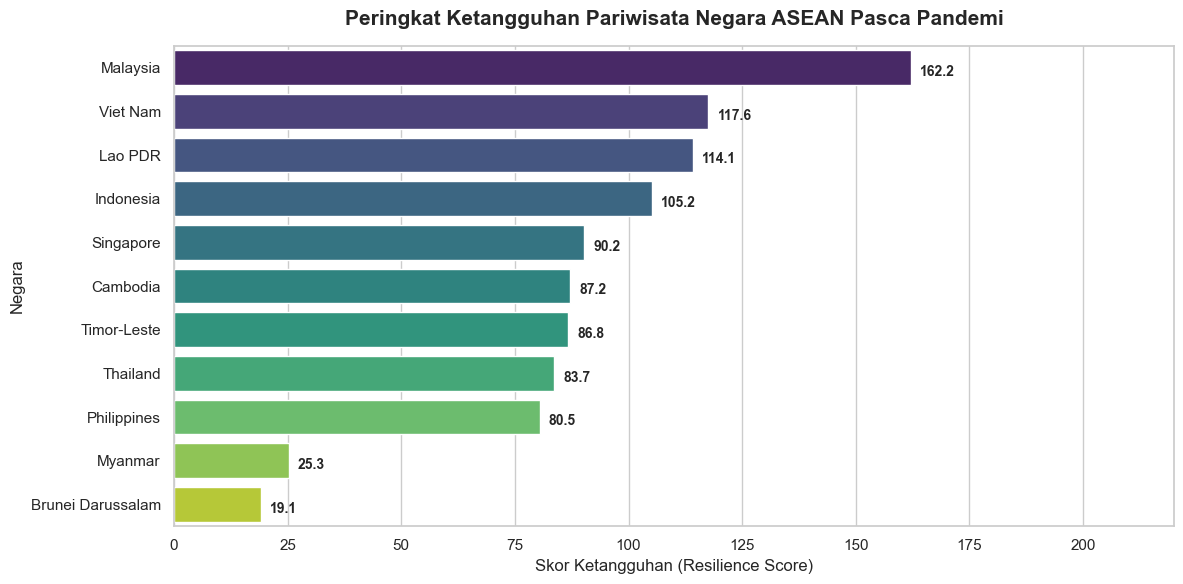

In [5]:
# 1. Perbandingan Skor Ketangguhan antar Negara ASEAN
plt.figure(figsize=(12, 6))
colors = sns.color_palette("viridis", len(df_ranking))
ax = sns.barplot(x='Resilience Score', y='Negara', data=df_ranking, palette=colors)

# Tambahkan label nilai di ujung bar
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 2, p.get_y() + p.get_height()/2 + 0.1, 
            f'{width:.1f}', 
            ha="left", va="center", fontsize=10, fontweight='bold')

plt.title('Peringkat Ketangguhan Pariwisata Negara ASEAN Pasca Pandemi', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Skor Ketangguhan (Resilience Score)', fontsize=12)
plt.ylabel('Negara', fontsize=12)
plt.xlim(0, 220)
plt.tight_layout()
plt.show()

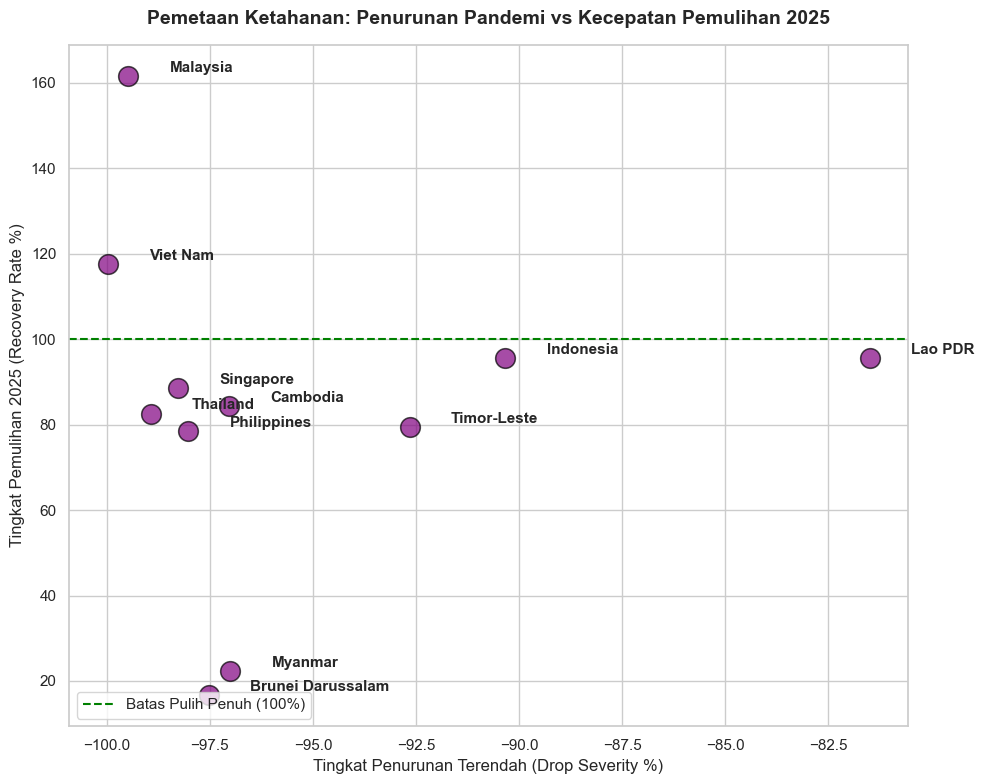

In [6]:
# 2. Scatter Plot: Drop Severity vs Recovery Rate
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Drop Severity (%)', y='Recovery Rate 2025 (%)', data=df_ranking, s=200, color='purple', alpha=0.7, edgecolor='black')

# Berikan anotasi nama negara pada dot
for idx, row in df_ranking.iterrows():
    plt.text(row['Drop Severity (%)'] + 1, row['Recovery Rate 2025 (%)'] + 1, 
             row['Negara'], fontsize=11, fontweight='semibold')

# Tambahkan garis batas pemulihan 100%
plt.axhline(100, color='green', linestyle='--', linewidth=1.5, label='Batas Pulih Penuh (100%)')

plt.title('Pemetaan Ketahanan: Penurunan Pandemi vs Kecepatan Pemulihan 2025', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tingkat Penurunan Terendah (Drop Severity %)', fontsize=12)
plt.ylabel('Tingkat Pemulihan 2025 (Recovery Rate %)', fontsize=12)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 7. Pemodelan & Peramalan (Forecasting 2026-2027)
Untuk memperkirakan lintasan pertumbuhan kunjungan di tahun 2026 dan 2027, kita memodelkan pertumbuhan dengan **Regresi Linier** pada masa pemulihan (2021 hingga 2025). Menggunakan data tahun 2019-2020 untuk meramal akan menyebabkan bias ke bawah yang tidak realistis karena anomali karantina.

In [7]:
forecast_results = {}

for _, row in df_clean.iterrows():
    country = row['destination_country']
    
    # Siapkan data training dari fase pemulihan (2021-2025)
    x_train = []
    y_train = []
    
    for yr in ['2021', '2022', '2023', '2024', '2025']:
        val = row[yr]
        if not pd.isna(val):
            x_train.append(int(yr))
            y_train.append(val)
            
    if len(x_train) >= 2:
        # Fit Linear Regression
        slope, intercept = np.polyfit(x_train, y_train, 1)
        # Prediksi 2026 dan 2027
        pred_2026 = max(0, int(slope * 2026 + intercept))
        pred_2027 = max(0, int(slope * 2027 + intercept))
        
        forecast_results[country] = {
            '2026': pred_2026,
            '2027': pred_2027,
            'Growth_Rate_Pct': round(((pred_2027 - row['2025']) / row['2025']) * 100, 2) if row['2025'] > 0 else 0
        }

df_forecast = pd.DataFrame.from_dict(forecast_results, orient='index').reset_index().rename(columns={'index': 'Negara'})
df_forecast

,Negara,2026,2027,Growth_Rate_Pct
0,ASEAN,203105477,241539250,64.26
1,Brunei Darussalam,1274868,1402377,89.24
2,Cambodia,8590249,10107251,81.47
3,Indonesia,20606873,24218574,57.40
4,Lao PDR,5993942,7050166,53.91
5,Malaysia,55705637,66907122,58.56
6,Myanmar,1491365,1742786,79.07
7,Philippines,8921097,10514682,62.16
8,Singapore,23752453,28090861,66.12
9,Thailand,48495866,57444425,74.21


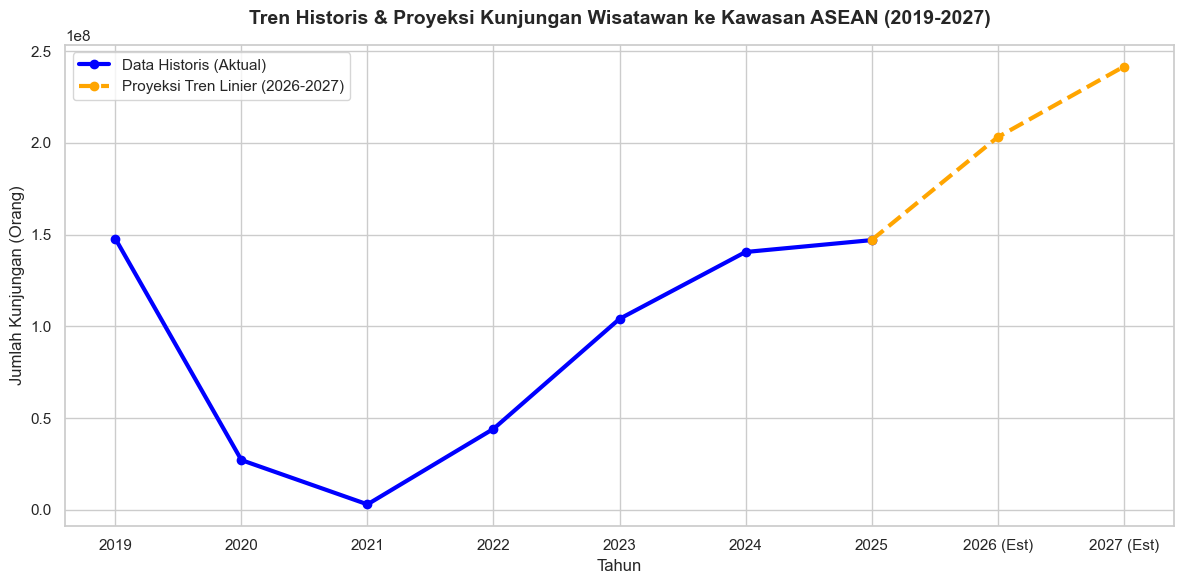

In [8]:
# Plot Visualisasi Proyeksi Pemulihan ASEAN (Regional)
asean_row = df_clean[df_clean['destination_country'] == 'ASEAN'].iloc[0]
asean_hist = [asean_row[str(yr)] for yr in range(2019, 2026)]
asean_proj = [np.nan]*6 + [asean_row['2025'], forecast_results['ASEAN']['2026'], forecast_results['ASEAN']['2027']]

years_all = [str(yr) for yr in range(2019, 2026)] + ['2026 (Est)', '2027 (Est)']

plt.figure(figsize=(12, 6))
plt.plot(years_all[:7], asean_hist, marker='o', linewidth=3, color='blue', label='Data Historis (Aktual)')
plt.plot(years_all[6:], asean_proj[6:], marker='o', linestyle='--', linewidth=3, color='orange', label='Proyeksi Tren Linier (2026-2027)')

plt.title('Tren Historis & Proyeksi Kunjungan Wisatawan ke Kawasan ASEAN (2019-2027)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Kunjungan (Orang)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 8. Ekspor Analisis ke JSON untuk Web Dashboard
Terakhir, kita susun data lengkap historis, metrik ketangguhan, dan prediksi untuk mempermudah pemuatan (*loading*) data di aplikasi dashboard interaktif.

In [ ]:
output_data = []

for _, row in df_clean.iterrows():
    country = row['destination_country']
    
    # Data historis
    history = {}
    for yr in ['2019', '2020', '2021', '2022', '2023', '2024', '2025']:
        val = row[yr]
        history[yr] = int(val) if not pd.isna(val) else None
        
    # Ambil metrik
    m_row = df_metrics[df_metrics['Negara'] == country].iloc[0]
    
    output_data.append({
        'country': country,
        'history': history,
        'metrics': {
            'drop_severity_pct': m_row['Drop Severity (%)'],
            'drop_retained_pct': round(100 + m_row['Drop Severity (%)'], 2),
            'recovery_rate_2025_pct': m_row['Recovery Rate 2025 (%)'],
            'years_to_recover': m_row['Tahun Pulih'],
            'resilience_score': m_row['Resilience Score']
        },
        'forecast': {
            '2026': forecast_results[country]['2026'],
            '2027': forecast_results[country]['2027']
        }
    })

with open('data.json', 'w') as f:
    json.dump(output_data, f, indent=2)